In [2]:
!pip install torch

  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 53.9 MB/s  0:00:014.5 MB/s eta 0:00:01:01
Using cached fsspec-2026.3.0-py3-none-any.whl (202 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 46.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 53.1 MB/s  0:00:00
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [torch]━━━━━ 5/6 [torch]kx]mpy]


In [3]:
import torch
print(torch.__version__)

2.11.0


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

print(f'PyTorch: {torch.__version__}')
print(f'GPU disponible: {torch.cuda.is_available()}')

PyTorch: 2.11.0
GPU disponible: False


In [5]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


In [ ]:
df = pd.read_csv('raw_data/combined_energy_price_clean.csv', sep='\t')

# some cleaning
prophet_df = df[(df['AreaDisplayName'] == 'DE-LU') & (df['Sequence'] == 2)][['DateTime(UTC)', 'Price[Currency/MWh]']].copy()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
prophet_df = prophet_df.dropna().sort_values('ds').reset_index(drop=True)

# Resamplear time
prophet_df = prophet_df.set_index('ds').resample('h').mean().reset_index()
prophet_df = prophet_df.dropna().reset_index(drop=True)

print(prophet_df.shape)

(46558, 2)


/var/folders/6p/0b4w1hy94rg79cl81qv1csjc0000gn/T/ipykernel_22482/2854722753.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('raw_data/combined_energy_price_clean.csv', sep='\t')


In [ ]:
# Limpiar Sequence
df['Sequence'] = df['Sequence'].astype(str).str.strip()

# Tomar Sequence 2 de DE-LU + los vacíos de DE-AT-LU (pre-2018)
df_clean = df[((df['AreaDisplayName'] == 'DE-LU') & (df['Sequence'] == '2')) |
              ((df['AreaDisplayName'] == 'DE-AT-LU') & (df['Sequence'] == ''))][['DateTime(UTC)', 'Price[Currency/MWh]']].copy()

df_clean.columns = ['ds', 'y']
df_clean['ds'] = pd.to_datetime(df_clean['ds'])
df_clean = df_clean.dropna().sort_values('ds').reset_index(drop=True)

# Resamplear a horario
df_clean = df_clean.set_index('ds').resample('h').mean().reset_index()
df_clean = df_clean.dropna().reset_index(drop=True)

print(df_clean.shape)
print(df_clean['ds'].min(), '→', df_clean['ds'].max())

(98974, 2)
2015-01-04 23:00:00 → 2026-04-21 21:00:00


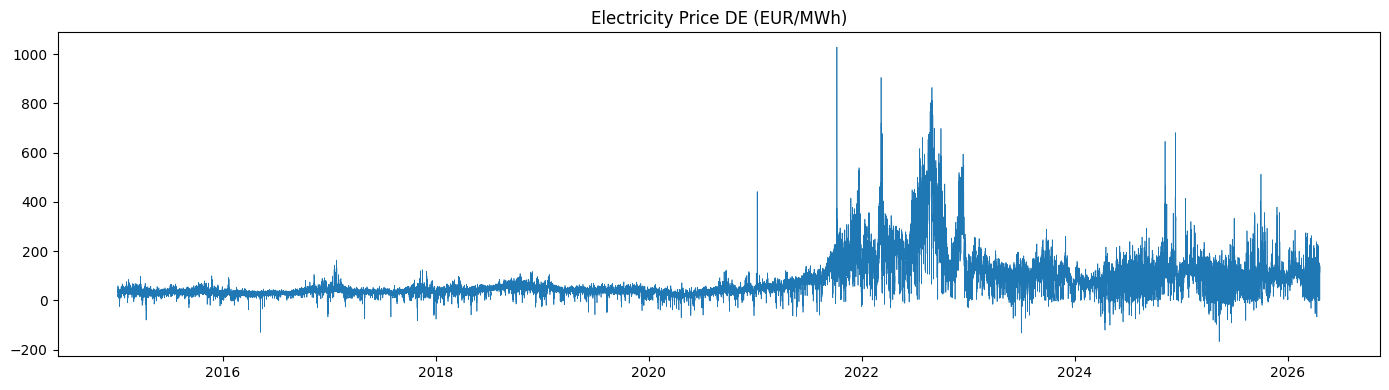

In [13]:
plt.figure(figsize=(14, 4))
plt.plot(df_clean['ds'], df_clean['y'], linewidth=0.5)
plt.title('Electricity Price DE (EUR/MWh)')
plt.tight_layout()
plt.show()

In [ ]:
# Cap outliers
df_clean['y'] = df_clean['y'].clip(upper=500)

# scaling
scaler = MinMaxScaler()
df_clean['y_scaled'] = scaler.fit_transform(df_clean[['y']])

# verify
df_clean.head()

,ds,y,y_scaled
0,2015-01-04 23:00:00,22.34,0.284292
1,2015-01-05 00:00:00,17.93,0.277684
2,2015-01-05 01:00:00,15.17,0.273549
3,2015-01-05 02:00:00,16.38,0.275362
4,2015-01-05 03:00:00,17.38,0.276860


In [16]:
def create_sequences(data, seq_len=24):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

# 24hrs winds
seq_len = 24
values = df_clean['y_scaled'].values

X, y = create_sequences(values, seq_len)
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (98950, 24)
y shape: (98950,)


In [17]:
# 80% train, 20% test
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Cconvert to tensors
X_train = torch.FloatTensor(X_train).unsqueeze(-1).to(device)
X_test = torch.FloatTensor(X_test).unsqueeze(-1).to(device)
y_train = torch.FloatTensor(y_train).to(device)
y_test = torch.FloatTensor(y_test).to(device)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')

X_train: torch.Size([79160, 24, 1])
X_test:  torch.Size([19790, 24, 1])


In [18]:
class TransformerModel(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x.squeeze(-1)

model = TransformerModel().to(device)
print(model)

TransformerModel(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# DataLoader for batches
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

# Training
epochs = 20
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.6f}')

Epoch 5/20 — Loss: 0.000631
Epoch 10/20 — Loss: 0.000556
Epoch 15/20 — Loss: 0.000503
Epoch 20/20 — Loss: 0.000492


In [23]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test)

# descaling
y_pred_np = scaler.inverse_transform(y_pred.cpu().numpy().reshape(-1, 1)).flatten()
y_test_np = scaler.inverse_transform(y_test.cpu().numpy().reshape(-1, 1)).flatten()

# metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_np, y_pred_np)
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))

print(f'mae:  {mae:.2f} EUR/MWh')
print(f'rmse: {rmse:.2f} EUR/MWh')

mae:  19.11 EUR/MWh
rmse: 23.45 EUR/MWh


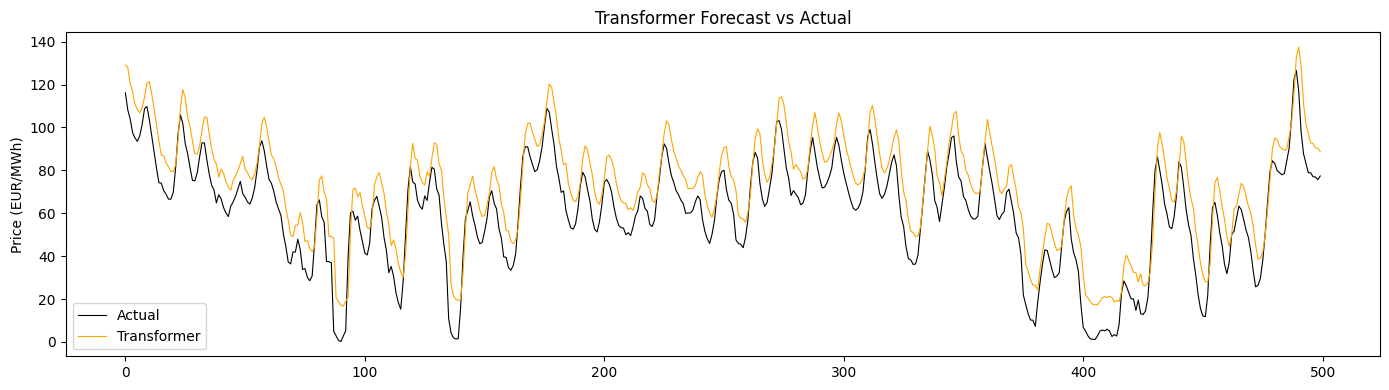

In [21]:
plt.figure(figsize=(14, 4))
plt.plot(y_test_np[:500], label='Actual', color='black', linewidth=0.8)
plt.plot(y_pred_np[:500], label='Transformer', color='orange', linewidth=0.8)
plt.title('Transformer Forecast vs Actual')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_feat = df_clean.copy()

# temporal features
df_feat['hour'] = df_feat['ds'].dt.hour
df_feat['day_of_week'] = df_feat['ds'].dt.dayofweek
df_feat['day_of_year'] = df_feat['ds'].dt.dayofyear
df_feat['month'] = df_feat['ds'].dt.month
df_feat['year'] = df_feat['ds'].dt.year

df_feat.head()

,ds,y,y_scaled,hour,day_of_week,day_of_year,month,year
0,2015-01-04 23:00:00,22.34,0.284292,23,6,4,1,2015
1,2015-01-05 00:00:00,17.93,0.277684,0,0,5,1,2015
2,2015-01-05 01:00:00,15.17,0.273549,1,0,5,1,2015
3,2015-01-05 02:00:00,16.38,0.275362,2,0,5,1,2015
4,2015-01-05 03:00:00,17.38,0.276860,3,0,5,1,2015


In [27]:
# Lags
df_feat['lag_1h'] = df_feat['y'].shift(1)
df_feat['lag_24h'] = df_feat['y'].shift(24)
df_feat['lag_168h'] = df_feat['y'].shift(168)  # 1 semana

# Moving averages
df_feat['ma_24h'] = df_feat['y'].rolling(24).mean()
df_feat['ma_168h'] = df_feat['y'].rolling(168).mean()

#
df_feat = df_feat.dropna().reset_index(drop=True)

print(df_feat.shape)
df_feat.head()

(98470, 13)


,ds,y,y_scaled,hour,day_of_week,day_of_year,month,year,lag_1h,lag_24h,lag_168h,ma_24h,ma_168h
0,2015-01-25 23:00:00,26.93,0.291169,23,6,25,1,2015,28.07,23.26,27.92,28.427917,39.829643
1,2015-01-26 00:00:00,26.13,0.289971,0,0,26,1,2015,26.93,22.13,27.76,28.594583,39.819940
2,2015-01-26 01:00:00,25.54,0.289087,1,0,26,1,2015,26.13,19.04,28.25,28.865417,39.803810
3,2015-01-26 02:00:00,25.41,0.288892,2,0,26,1,2015,25.54,19.91,28.41,29.094583,39.785952
4,2015-01-26 03:00:00,25.80,0.289476,3,0,26,1,2015,25.41,21.49,28.07,29.274167,39.772440


In [28]:
# Features que vamos a usar
feature_cols = ['y_scaled', 'hour', 'day_of_week', 'day_of_year', 'month', 'year',
                'lag_1h', 'lag_24h', 'lag_168h', 'ma_24h', 'ma_168h']

# Escalar todo entre 0 y 1
from sklearn.preprocessing import MinMaxScaler

scaler_feat = MinMaxScaler()
df_feat[feature_cols] = scaler_feat.fit_transform(df_feat[feature_cols])

print(f'Features: {len(feature_cols)}')
df_feat[feature_cols].head()


Features: 11


,y_scaled,hour,day_of_week,day_of_year,month,year,lag_1h,lag_24h,lag_168h,ma_24h,ma_168h
0,0.291169,1.000000,1.0,0.065753,0.0,0.0,0.292878,0.285670,0.292653,0.161138,0.062809
1,0.289971,0.000000,0.0,0.068493,0.0,0.0,0.291169,0.283977,0.292413,0.161434,0.062789
2,0.289087,0.043478,0.0,0.068493,0.0,0.0,0.289971,0.279347,0.293147,0.161916,0.062754
3,0.288892,0.086957,0.0,0.068493,0.0,0.0,0.289087,0.280651,0.293387,0.162324,0.062716
4,0.289476,0.130435,0.0,0.068493,0.0,0.0,0.288892,0.283018,0.292878,0.162643,0.062687


In [29]:
def create_sequences_multi(data, seq_len=24):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, 0])  # target es y_scaled (col 0)
    return np.array(X), np.array(y)

values = df_feat[feature_cols].values
X, y = create_sequences_multi(values, seq_len=24)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (98446, 24, 11)
y shape: (98446,)


In [30]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = torch.FloatTensor(X_train).to(device)
X_test = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).to(device)
y_test = torch.FloatTensor(y_test).to(device)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')

X_train: torch.Size([78756, 24, 11])
X_test:  torch.Size([19690, 24, 11])


In [31]:
class TransformerModel(nn.Module):
    def __init__(self, input_size=11, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x.squeeze(-1)

model_multi = TransformerModel(input_size=11).to(device)
print(model_multi)

TransformerModel(
  (input_projection): Linear(in_features=11, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [32]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_multi.parameters(), lr=0.001)

dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

epochs = 20
for epoch in range(epochs):
    model_multi.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model_multi(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.6f}')

Epoch 5/20 — Loss: 0.000678
Epoch 10/20 — Loss: 0.000420
Epoch 15/20 — Loss: 0.000349
Epoch 20/20 — Loss: 0.000306


In [37]:
model_multi.eval()
with torch.no_grad():
    y_pred = model_multi(X_test)

y_pred_np = y_pred.cpu().numpy()
y_test_np_scaled = y_test.cpu().numpy()

y_pred_real = scaler_price.inverse_transform(y_pred_np.reshape(-1, 1)).flatten()
y_test_real = scaler_price.inverse_transform(y_test_np_scaled.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f'MAE:  {mae:.2f} EUR/MWh')
print(f'RMSE: {rmse:.2f} EUR/MWh')

MAE:  21.01 EUR/MWh
RMSE: 23.25 EUR/MWh


In [39]:
# ----------------------------------

In [38]:
# ---- FEATURE ENGINEERING ----
df_feat = df_clean.copy()

df_feat['hour'] = df_feat['ds'].dt.hour
df_feat['day_of_week'] = df_feat['ds'].dt.dayofweek
df_feat['day_of_year'] = df_feat['ds'].dt.dayofyear
df_feat['month'] = df_feat['ds'].dt.month
df_feat['year'] = df_feat['ds'].dt.year

df_feat['lag_1h'] = df_feat['y'].shift(1)
df_feat['lag_24h'] = df_feat['y'].shift(24)
df_feat['lag_168h'] = df_feat['y'].shift(168)
df_feat['ma_24h'] = df_feat['y'].rolling(24).mean()
df_feat['ma_168h'] = df_feat['y'].rolling(168).mean()

df_feat = df_feat.dropna().reset_index(drop=True)

# ---- SCALING ----
# Precio por separado
scaler_price = MinMaxScaler()
df_feat['y_scaled'] = scaler_price.fit_transform(df_feat[['y']])

# Resto de features
other_cols = ['hour', 'day_of_week', 'day_of_year', 'month', 'year',
              'lag_1h', 'lag_24h', 'lag_168h', 'ma_24h', 'ma_168h']
scaler_other = MinMaxScaler()
df_feat[other_cols] = scaler_other.fit_transform(df_feat[other_cols])

# ---- SECUENCIAS ----
feature_cols = ['y_scaled'] + other_cols
values = df_feat[feature_cols].values
X, y = create_sequences_multi(values, seq_len=24)

print(f'X: {X.shape}, y: {y.shape}')

# ---- SPLIT ----
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = torch.FloatTensor(X_train).to(device)
X_test = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).to(device)
y_test = torch.FloatTensor(y_test).to(device)

X: (98782, 24, 11), y: (98782,)


In [40]:
model_multi = TransformerModel(input_size=11).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_multi.parameters(), lr=0.001)

dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

epochs = 20
for epoch in range(epochs):
    model_multi.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model_multi(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.6f}')

Epoch 5/20 — Loss: 0.000271
Epoch 10/20 — Loss: 0.000258
Epoch 15/20 — Loss: 0.000244


KeyboardInterrupt: 

In [ ]:
model_multi.eval()
with torch.no_grad():
    y_pred = model_multi(X_test)

y_pred_np = y_pred.cpu().numpy()
y_test_np_scaled = y_test.cpu().numpy()

y_pred_real = scaler_price.inverse_transform(y_pred_np.reshape(-1, 1)).flatten()
y_test_real = scaler_price.inverse_transform(y_test_np_scaled.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f'MAE:  {mae:.2f} EUR/MWh')
print(f'RMSE: {rmse:.2f} EUR/MWh')